# Базовый блок. Архитектура автокодировщика (Autoencoder). ДЗ Lite — PyTorch

## Задание

Добейтесь на автокодировщике с 2-мерным скрытым пространством на 3-х цифрах: 0, 1 и 3 — ошибки MSE < 0.034 на скорости обучения 0.001 на 10-й эпохе.

**Реализация на PyTorch.**

## Импорт библиотек

In [1]:
# Работа с операционной системой
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

# Операции с путями
import glob

# Работа с массивами данных
import numpy as np

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Датасет MNIST берём из Keras (как в исходном задании) —
# это всего лишь источник массивов numpy, сама модель будет на PyTorch.
from tensorflow.keras.datasets import mnist

%matplotlib inline

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)

# Фиксируем сиды для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)

Устройство: cuda


## Утилиты

Функция-коллбэк. Отрисовывает объекты в скрытом пространстве (аналог `ae_on_epoch_end`, переписанный под PyTorch).

In [2]:
def ae_on_epoch_end(epoch, loss_value, encoder, X_train_t, y_train_np):
    print('______________________________________')
    print(f'*** ЭПОХА: {epoch+1}, loss: {loss_value} ***')
    print('______________________________________')

    # Задание числа пикселей на дюйм
    plt.figure(dpi=100)

    # Предсказание энкодера на тренировочной выборке (без подсчёта градиентов)
    encoder.eval()
    with torch.no_grad():
        predict = encoder(X_train_t.to(device)).cpu().numpy()
    encoder.train()

    # Создание рисунка: множество точек на плоскости 3-х цветов (3-х классов)
    scatter = plt.scatter(predict[:, 0], predict[:, 1], c=y_train_np, alpha=0.6, s=5)

    # Создание легенды
    legend2 = plt.legend(*scatter.legend_elements(), loc='upper right', title='Классы')

    # Сохранение картинки с названием, которого ещё нет
    paths = glob.glob('*.jpg')
    plt.savefig(f'image_{str(len(paths))}.jpg')

    # Отображение
    plt.show()

Удаление изображений. Применять при обучении новой модели, чтобы не было путаницы в картинках.

In [3]:
def clean():
    # Получение названий всех картинок
    paths = glob.glob('*.jpg')
    # Удаление всех картинок по полученным путям
    for p in paths:
        os.remove(p)

# Удаление всех картинок
clean()

## Загрузка данных

In [4]:
# Загрузка датасета
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Нормировка. В PyTorch используем формат NCHW: (N, 1, 28, 28)
X_train = X_train.astype('float32') / 255.
X_train = X_train.reshape(-1, 1, 28, 28)

In [6]:
# Выбор визуализируемых классов (цифр) и формирование подвыборок для них по маске
numbers = [0, 1, 3]
mask = np.array([(i in numbers) for i in y_train])
X_train = X_train[mask]
y_train = y_train[mask]

print('Размер обучающей выборки:', X_train.shape)

Размер обучающей выборки: (18796, 1, 28, 28)


## Создание модели и обучение

### Решение (PyTorch)

In [7]:
# Энкодер: изображение 1x28x28 -> латентный вектор размерности 2
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),       # 32 x 28 x 28
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                      # 32 x 14 x 14

            nn.Conv2d(32, 64, 3, padding=1),      # 64 x 14 x 14
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                      # 64 x 7 x 7

            nn.Conv2d(64, 128, 3, padding=1),     # 128 x 7 x 7
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Flatten(),                         # 128*7*7 = 6272
            nn.Linear(128 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 2)                      # латентное пространство (linear)
        )

    def forward(self, x):
        return self.net(x)

# Декодер: латентный вектор размерности 2 -> изображение 1x28x28
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 128 * 7 * 7),
            nn.ReLU(),
        )
        self.deconv = nn.Sequential(
            # 128 x 7 x 7 -> 64 x 14 x 14
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # 64 x 14 x 14 -> 32 x 28 x 28
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # 32 x 28 x 28 -> 1 x 28 x 28
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 7, 7)
        return self.deconv(x)

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        return self.decoder(self.encoder(x))

autoencoder = Autoencoder().to(device)
encoder = autoencoder.encoder      # ссылка, нужна коллбэку
print(autoencoder)

Autoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Flatten(start_dim=1, end_dim=-1)
      (12): Linear(in_features=6272, out_features=64, bias=True)
      (13): ReLU()
      (14): Linear(in_features=64, out_features=2, bias=True)
    )
  )
  (decode

In [8]:
# Данные в тензоры
X_train_t = torch.from_numpy(X_train)                       # (N, 1, 28, 28) float32
dataset = TensorDataset(X_train_t, X_train_t)               # вход = выход
loader = DataLoader(dataset, batch_size=128, shuffle=True)

# Оптимизатор Adam с learning_rate = 0.001, функция потерь MSE
criterion = nn.MSELoss()                                    # среднее по всем элементам — как в Keras 'mse'
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

______________________________________
*** ЭПОХА: 1, loss: 0.05004351729914391 ***
______________________________________


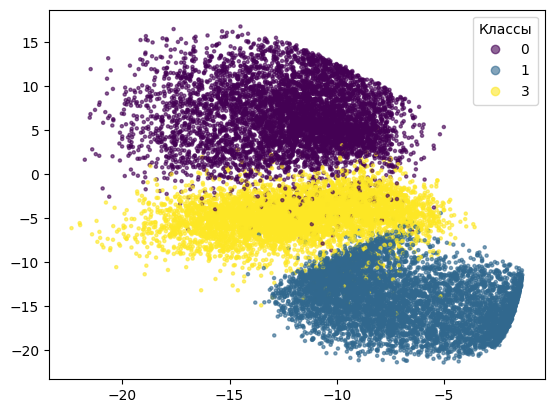

______________________________________
*** ЭПОХА: 2, loss: 0.032700855747122136 ***
______________________________________


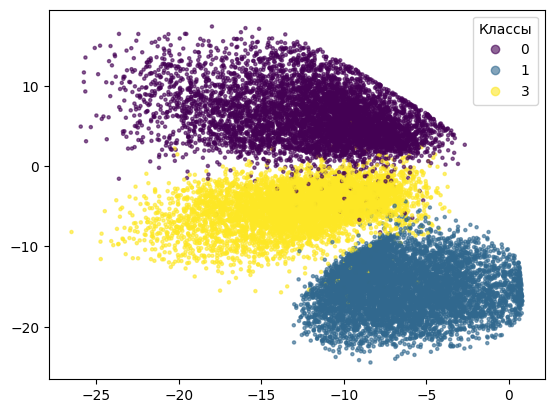

______________________________________
*** ЭПОХА: 3, loss: 0.030142738602169147 ***
______________________________________


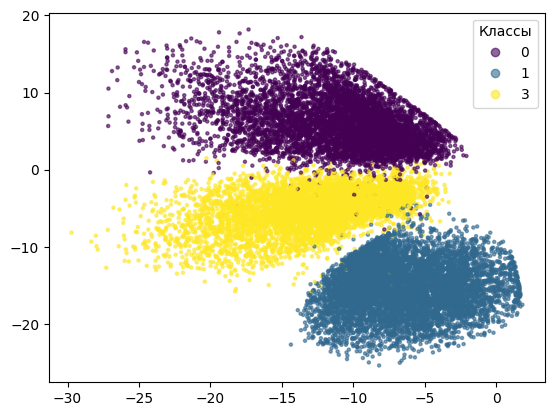

______________________________________
*** ЭПОХА: 4, loss: 0.029336517430948155 ***
______________________________________


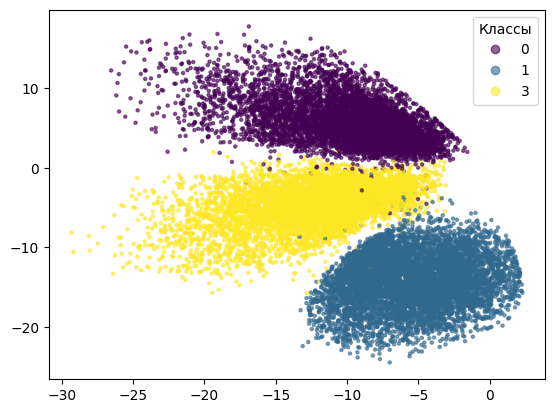

______________________________________
*** ЭПОХА: 5, loss: 0.02886955032077945 ***
______________________________________


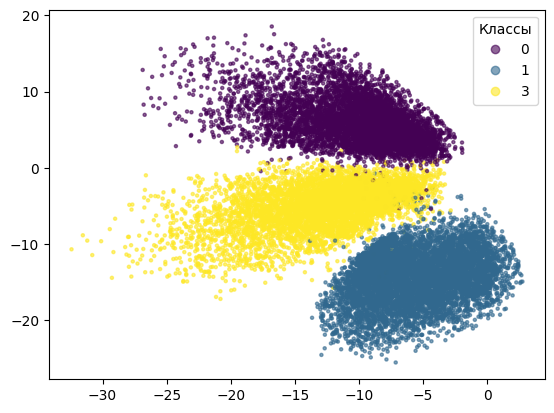

______________________________________
*** ЭПОХА: 6, loss: 0.028429181333437047 ***
______________________________________


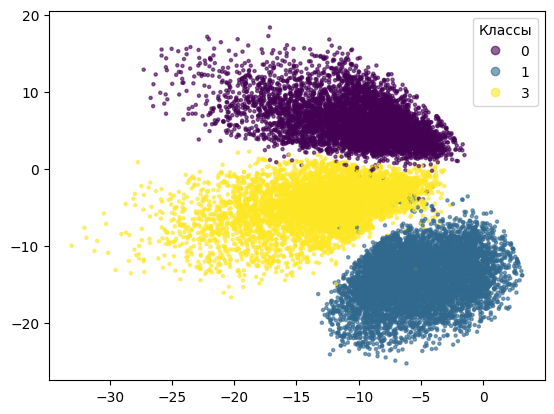

______________________________________
*** ЭПОХА: 7, loss: 0.02821568194455696 ***
______________________________________


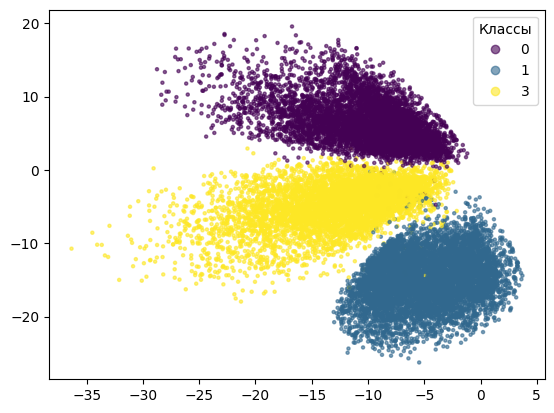

______________________________________
*** ЭПОХА: 8, loss: 0.02791730940673333 ***
______________________________________


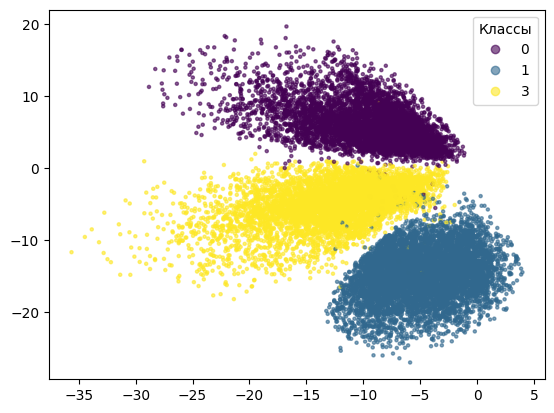

______________________________________
*** ЭПОХА: 9, loss: 0.02788082026515991 ***
______________________________________


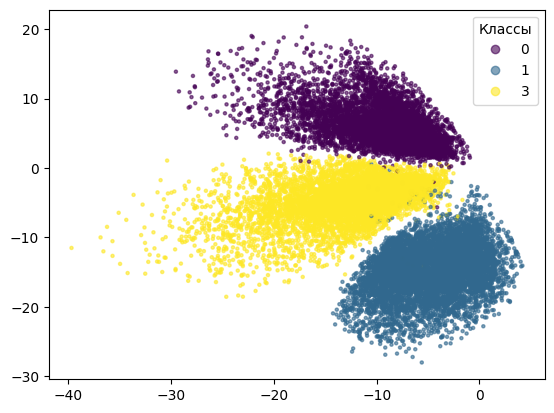

______________________________________
*** ЭПОХА: 10, loss: 0.027664662635096163 ***
______________________________________


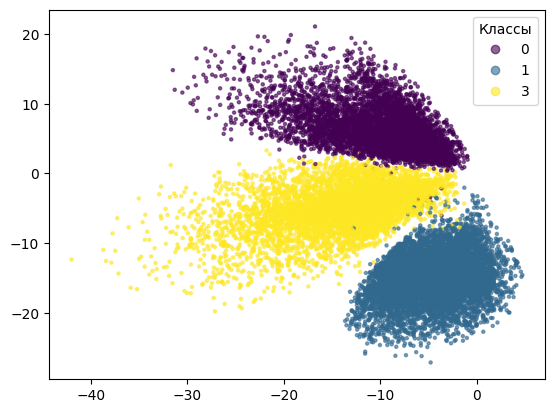

In [9]:
# Обучение в течение 10 эпох с визуализацией латентного пространства после каждой эпохи
clean()

EPOCHS = 10
loss_history = []

for epoch in range(EPOCHS):
    autoencoder.train()
    running_loss = 0.0
    n_samples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        out = autoencoder(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        # Накапливаем взвешенно по размеру батча, чтобы получить
        # корректное среднее по эпохе (эквивалент Keras epoch loss)
        running_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)

    epoch_loss = running_loss / n_samples
    loss_history.append(epoch_loss)

    # Коллбэк: печать + отрисовка латентного пространства
    ae_on_epoch_end(epoch, epoch_loss, encoder, X_train_t, y_train)

In [10]:
# Итоговая MSE на 10-й эпохе
final_loss = loss_history[-1]
print(f'Финальная MSE на 10-й эпохе: {final_loss:.5f}')
print(f'Цель < 0.034: {"ДОСТИГНУТА" if final_loss < 0.034 else "НЕ ДОСТИГНУТА"}')

Финальная MSE на 10-й эпохе: 0.02766
Цель < 0.034: ДОСТИГНУТА


### График обучения

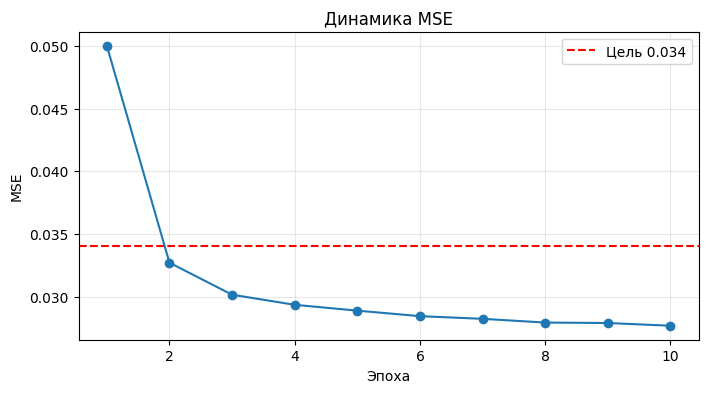

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.axhline(0.034, color='red', linestyle='--', label='Цель 0.034')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Динамика MSE')
plt.show()